<a href="https://colab.research.google.com/github/jeeen0/cv-2026-lab/blob/main/ex10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX.10-2

In [ ]:
pip install timm

--2026-05-25 00:18:01--  https://www.dropbox.com/scl/fi/nn4ff9p08zrj5e8201e0d/person.jpg?rlkey=c4n3gx6hi0qy8lto7djbseot5
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc0a8d3cf8f6421d6f86b69623eb.dl.dropboxusercontent.com/cd/0/inline/DBFnS8IxLO8K3drJB9mSS5PXvUAqPvGb2Fd4j_Tn5XwibW7bcvZczIRgZbV0s6fs4b2ECOw5sUHrQZida2fzNuN-8w14kLFg62ra5faVgjZevsdgCRvoQS72_f3drcoEax2QnoY_khQdg6F4sLugl7-5/file# [following]
--2026-05-25 00:18:01--  https://uc0a8d3cf8f6421d6f86b69623eb.dl.dropboxusercontent.com/cd/0/inline/DBFnS8IxLO8K3drJB9mSS5PXvUAqPvGb2Fd4j_Tn5XwibW7bcvZczIRgZbV0s6fs4b2ECOw5sUHrQZida2fzNuN-8w14kLFg62ra5faVgjZevsdgCRvoQS72_f3drcoEax2QnoY_khQdg6F4sLugl7-5/file
Resolving uc0a8d3cf8f6421d6f86b69623eb.dl.dropboxusercontent.com (uc0a8d3cf8f6421d6f86b69623eb.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100

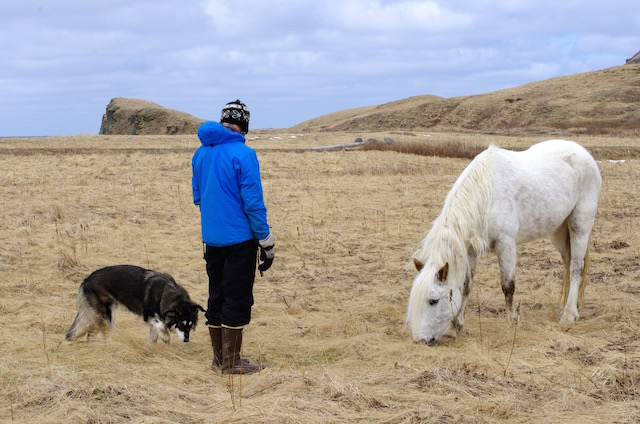

In [ ]:
import cv2
import torch
import urllib.request
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

#url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
#urllib.request.urlretrieve(url, filename)
!wget --content-disposition https://www.dropbox.com/scl/fi/nn4ff9p08zrj5e8201e0d/person.jpg?rlkey=c4n3gx6hi0qy8lto7djbseot5&dl=0
filename = "person.jpg"

img = cv2.imread(filename)
cv2_imshow(img)

In [ ]:
model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
#model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

midas = torch.hub.load("intel-isl/MiDaS", model_type)

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:21<00:00, 65.5MB/s]


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

DPTDepthModel(
  (pretrained): Module(
    (model): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
    

In [ ]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

In [ ]:
with torch.no_grad():
    prediction = midas(input_batch)

    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()

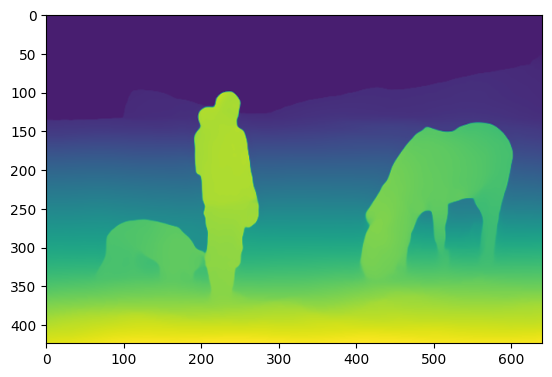

In [ ]:
plt.imshow(output)
# plt.show()